# **Prediksi Penyakit Ginjal Kronis Menggunakan Machine Learning Berdasarkan Indikator Kesehatan**

Kelompok 4 :
KHOFIFAH DWI SANNI EL RANDI

Dataset:https://www.kaggle.com/datasets/alitaqishah/ckd-nhanes-2021-2023-staged-kidney-disease

# IMPORT LIBRARY

In [90]:
!pip install shap -q

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# LOAD DATASET

In [92]:
df = pd.read_csv("CKD_NHANES_2021_2023.csv")

df.head()

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,...,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,...,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,...,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,...,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


In [93]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 11933
Jumlah kolom : 29


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  object 
 3   ethnicity                 11933 non-null  object 
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null   float64
 14  phosph

# DATA CLEANING

In [95]:
print("Jumlah ID unik:", df['participant_id'].nunique())
print("Jumlah baris:", len(df))

print("Jumlah duplikasi baris:", df.duplicated().sum())
print("Jumlah duplikasi participant_id:", df['participant_id'].duplicated().sum())

Jumlah ID unik: 11933
Jumlah baris: 11933
Jumlah duplikasi baris: 0
Jumlah duplikasi participant_id: 0


In [96]:
missing = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().mean() * 100).round(2)
})

missing = missing.sort_values('Missing', ascending=False)

missing

,Missing,Persentase (%)
insulin_use,10852,90.94
diabetes_pills,9652,80.88
current_smoker,8690,72.82
phosphorus,5611,47.02
bicarbonate,5608,47.00
blood_urea_nitrogen,5607,46.99
serum_creatinine,5607,46.99
egfr,5607,46.99
uric_acid,5604,46.96
calcium,5571,46.69


In [97]:
# AUDIT TARGET DAN eGFR

print("Distribusi ckd_present:")
print(df["ckd_present"].value_counts())

print("\nRata-rata eGFR berdasarkan target:")
print(df.groupby("ckd_present")["egfr"].agg(["count", "mean", "min", "max"]))

print("\nStatus ckd_stage berdasarkan target:")
print(pd.crosstab(df["ckd_stage"], df["ckd_present"]))

Distribusi ckd_present:
ckd_present
1    8341
0    3592
Name: count, dtype: int64

Rata-rata eGFR berdasarkan target:
             count        mean    min     max
ckd_present                                  
0             3592  111.371837  90.00  178.43
1             2734   77.191800   3.51  153.77

Status ckd_stage berdasarkan target:
ckd_present                      0     1
ckd_stage                               
No CKD                        3592     0
Stage 1 (Kidney Damage)          0   382
Stage 2 (Mildly Decreased)       0  1875
Stage 3a (Mild-Moderate)         0   341
Stage 3b (Moderate-Severe)       0    97
Stage 4 (Severely Decreased)     0    28
Stage 5 (Kidney Failure)         0    11
Unknown                          0  5607


In [98]:
egfr_missing = pd.crosstab(
    df["egfr"].isna(),
    df["ckd_present"],
    normalize="columns"
) * 100

egfr_missing.columns = ["Non-CKD", "CKD"]
egfr_missing.index = ["eGFR tersedia", "eGFR missing"]

egfr_missing.round(2)

,Non-CKD,CKD
eGFR tersedia,100.0,32.78
eGFR missing,0.0,67.22


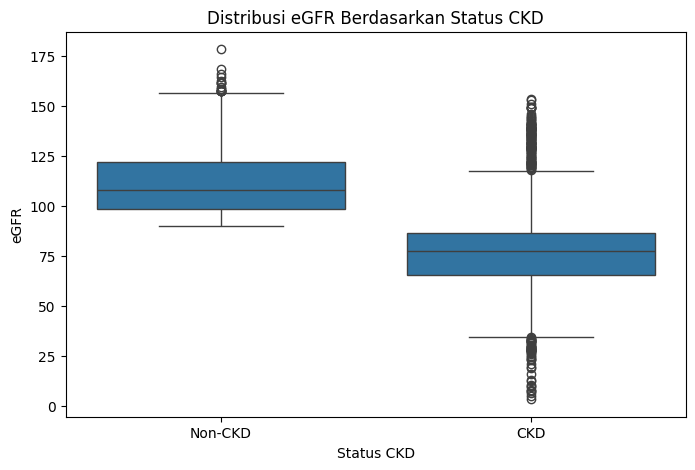

In [99]:
# VISUALISASI eGFR VS TARGET

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="ckd_present",
    y="egfr"
)

plt.xlabel("Status CKD")
plt.ylabel("eGFR")
plt.title("Distribusi eGFR Berdasarkan Status CKD")
plt.xticks([0, 1], ["Non-CKD", "CKD"])
plt.show()

In [100]:
missing_by_target = (
    df.drop(columns=["participant_id", "ckd_stage"])
      .groupby("ckd_present")
      .apply(lambda x: x.isna().mean() * 100)
      .T
)

missing_by_target.columns = ["Non-CKD", "CKD"]

missing_by_target["Selisih"] = (
    missing_by_target["CKD"] -
    missing_by_target["Non-CKD"]
)

missing_by_target.sort_values(
    "Selisih",
    ascending=False
).round(2)

,Non-CKD,CKD,Selisih
serum_creatinine,0.00,67.22,67.22
egfr,0.00,67.22,67.22
uric_acid,0.00,67.19,67.19
bicarbonate,0.06,67.21,67.15
blood_urea_nitrogen,0.06,67.20,67.14
phosphorus,0.28,67.15,66.87
albumin_serum,0.00,66.74,66.74
calcium,0.06,66.77,66.71
bp_systolic,3.40,51.48,48.08
bp_diastolic,3.40,51.48,48.08


In [101]:
df.describe()

,participant_id,age,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,...,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_present
count,11933.000000,1.193300e+04,7794.000000,9.892000e+03,8471.000000,8754.000000,8499.000000,7517.000000,7517.000000,6326.000000,...,8154.000000,8153.000000,8153.000000,11740.000000,1081.000000,2281.000000,8135.000000,3243.000000,6326.000000,11933.000000
mean,136344.000000,3.831786e+01,3.804978,2.708174e+00,27.246665,70.549037,159.664549,119.288546,72.748038,0.872828,...,133.258646,35.567928,33.355533,1.934497,1.681776,1.633494,1.611678,2.339500,96.599750,0.698986
std,3444.904716,2.560199e+01,1.153750,1.670119e+00,8.137781,30.389021,19.864943,18.561052,11.895572,0.385498,...,90.676053,175.582217,251.094041,0.358726,0.466002,0.635776,0.558182,0.900889,24.633731,0.458718
min,130378.000000,5.397605e-79,1.000000,5.397605e-79,11.100000,2.700000,79.100000,61.000000,33.000000,0.330000,...,4.000000,0.210000,0.080000,1.000000,1.000000,1.000000,1.000000,1.000000,3.510000,0.000000
25%,133361.000000,1.300000e+01,3.000000,1.180000e+00,21.600000,54.200000,154.400000,106.000000,64.000000,0.700000,...,65.000000,5.770000,5.420000,2.000000,1.000000,1.000000,1.000000,1.000000,80.502500,0.000000
50%,136344.000000,3.700000e+01,4.000000,2.500000e+00,26.400000,71.700000,163.600000,117.000000,72.000000,0.830000,...,117.000000,9.620000,8.270000,2.000000,2.000000,2.000000,2.000000,3.000000,97.030000,1.000000
75%,139327.000000,6.200000e+01,5.000000,4.500000e+00,31.700000,89.100000,172.100000,130.000000,80.000000,0.980000,...,181.000000,17.830000,15.330000,2.000000,2.000000,2.000000,2.000000,3.000000,112.660000,1.000000
max,142310.000000,8.000000e+01,9.000000,5.000000e+00,74.800000,248.200000,200.700000,232.000000,142.000000,15.170000,...,873.000000,7942.470000,14708.280000,9.000000,2.000000,9.000000,9.000000,3.000000,178.430000,1.000000


# EDA

In [102]:
df['ckd_present'].value_counts(dropna=False)

,count
ckd_present,
1,8341
0,3592


In [103]:
print(df["ckd_present"].unique())

[0 1]


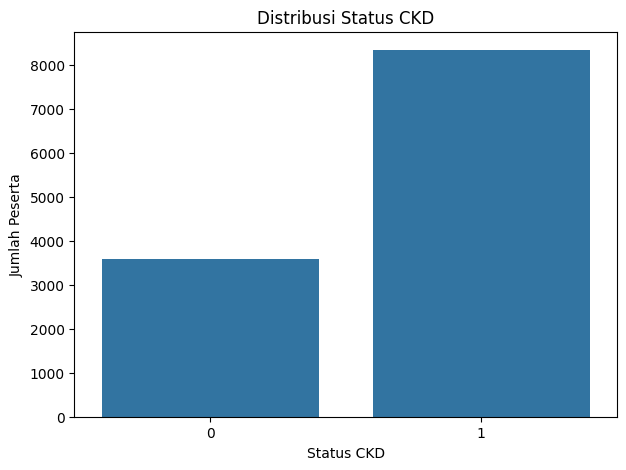

In [104]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='ckd_present'
)

plt.xlabel('Status CKD')
plt.ylabel('Jumlah Peserta')
plt.title('Distribusi Status CKD')
plt.show()

In [105]:
important_numeric = [
    "age",
    "bmi",
    "bp_systolic",
    "bp_diastolic",
    "serum_creatinine",
    "blood_urea_nitrogen",
    "albumin_serum",
    "uric_acid",
    "egfr"
]

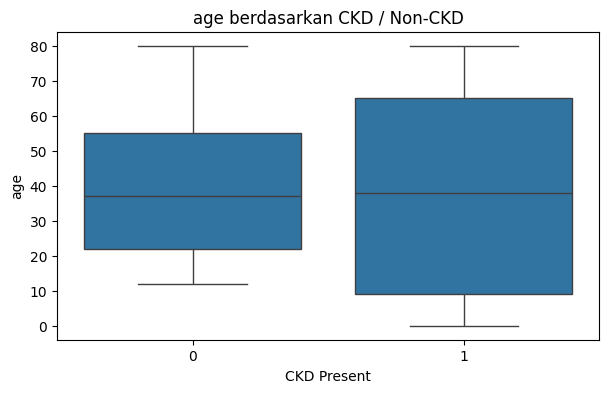

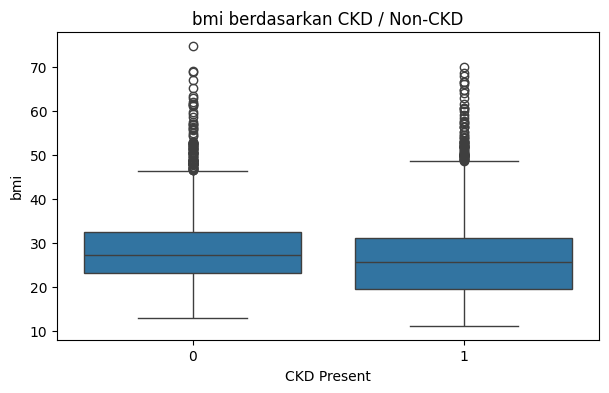

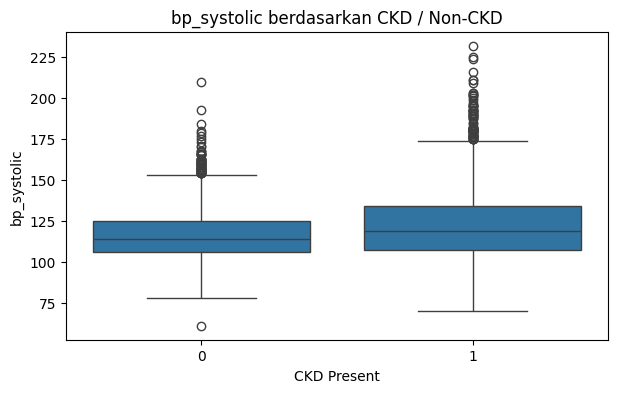

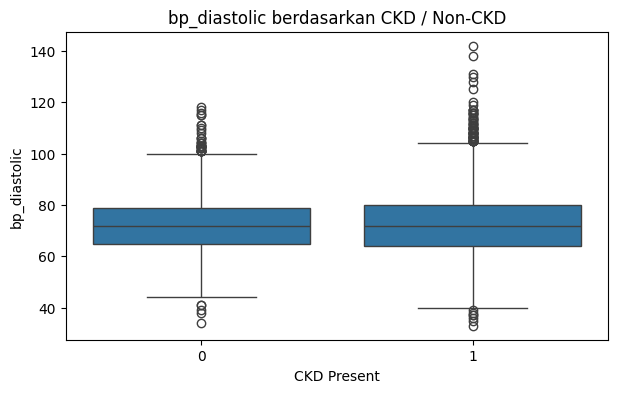

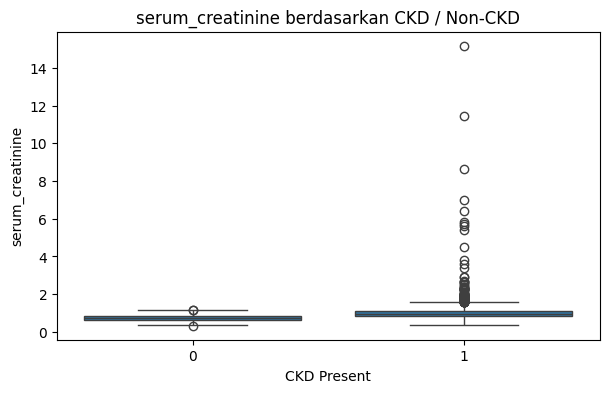

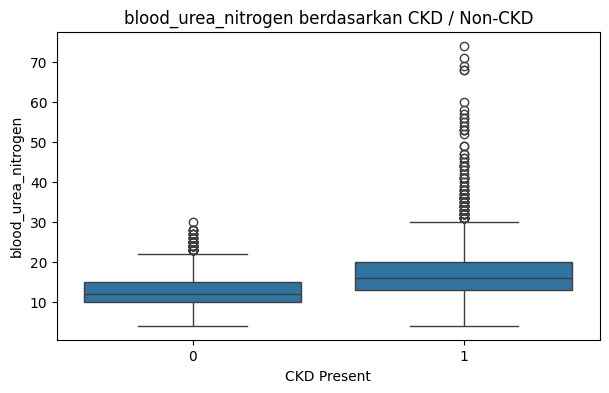

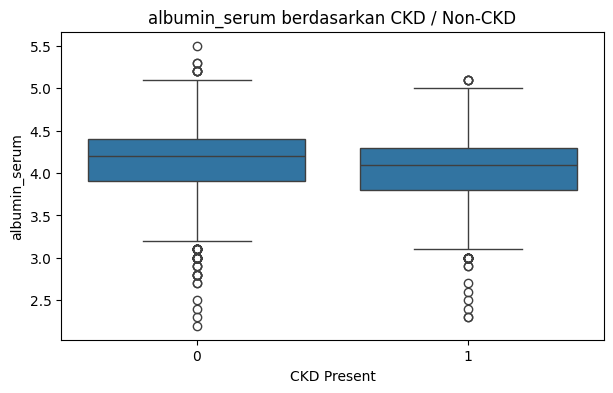

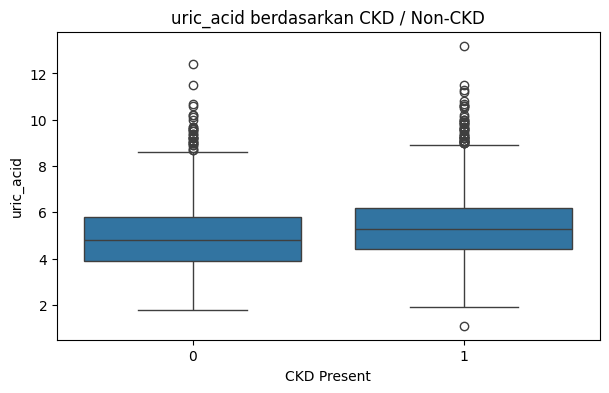

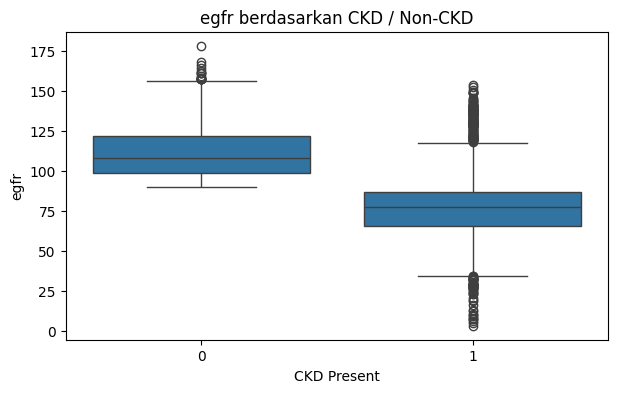

In [106]:
for col in important_numeric:

    if col in df.columns:

        plt.figure(figsize=(7, 4))

        sns.boxplot(
            data=df,
            x="ckd_present",
            y=col
        )

        plt.title(f"{col} berdasarkan CKD / Non-CKD")
        plt.xlabel("CKD Present")
        plt.ylabel(col)

        plt.show()

In [107]:
categorical_eda = [
    "gender",
    "diabetes_diagnosed",
    "ever_smoked",
    "current_smoker"
]

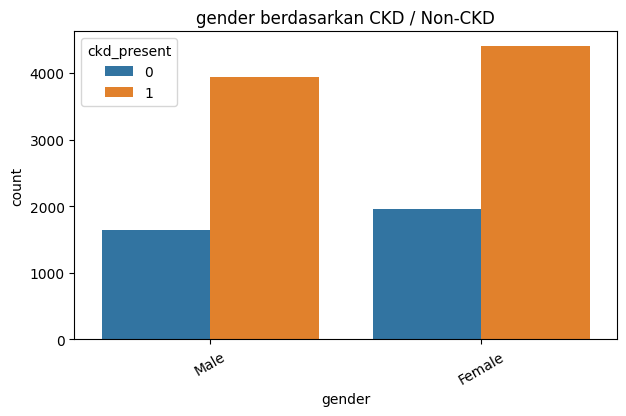

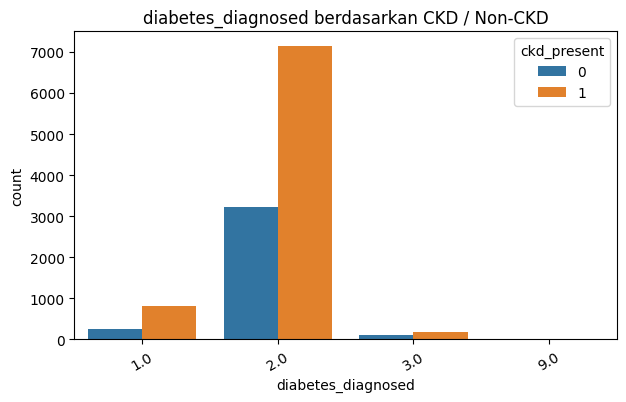

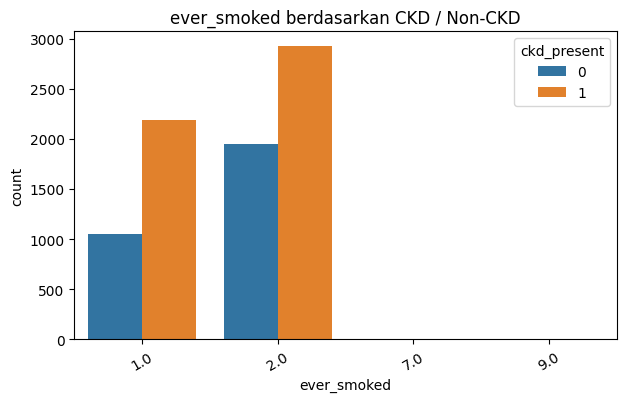

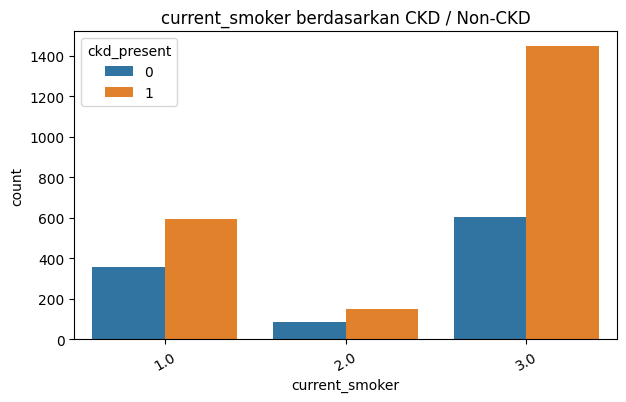

In [108]:
for col in categorical_eda:

    if col in df.columns:

        plt.figure(figsize=(7, 4))

        sns.countplot(
            data=df,
            x=col,
            hue="ckd_present"
        )

        plt.title(f"{col} berdasarkan CKD / Non-CKD")
        plt.xticks(rotation=30)

        plt.show()

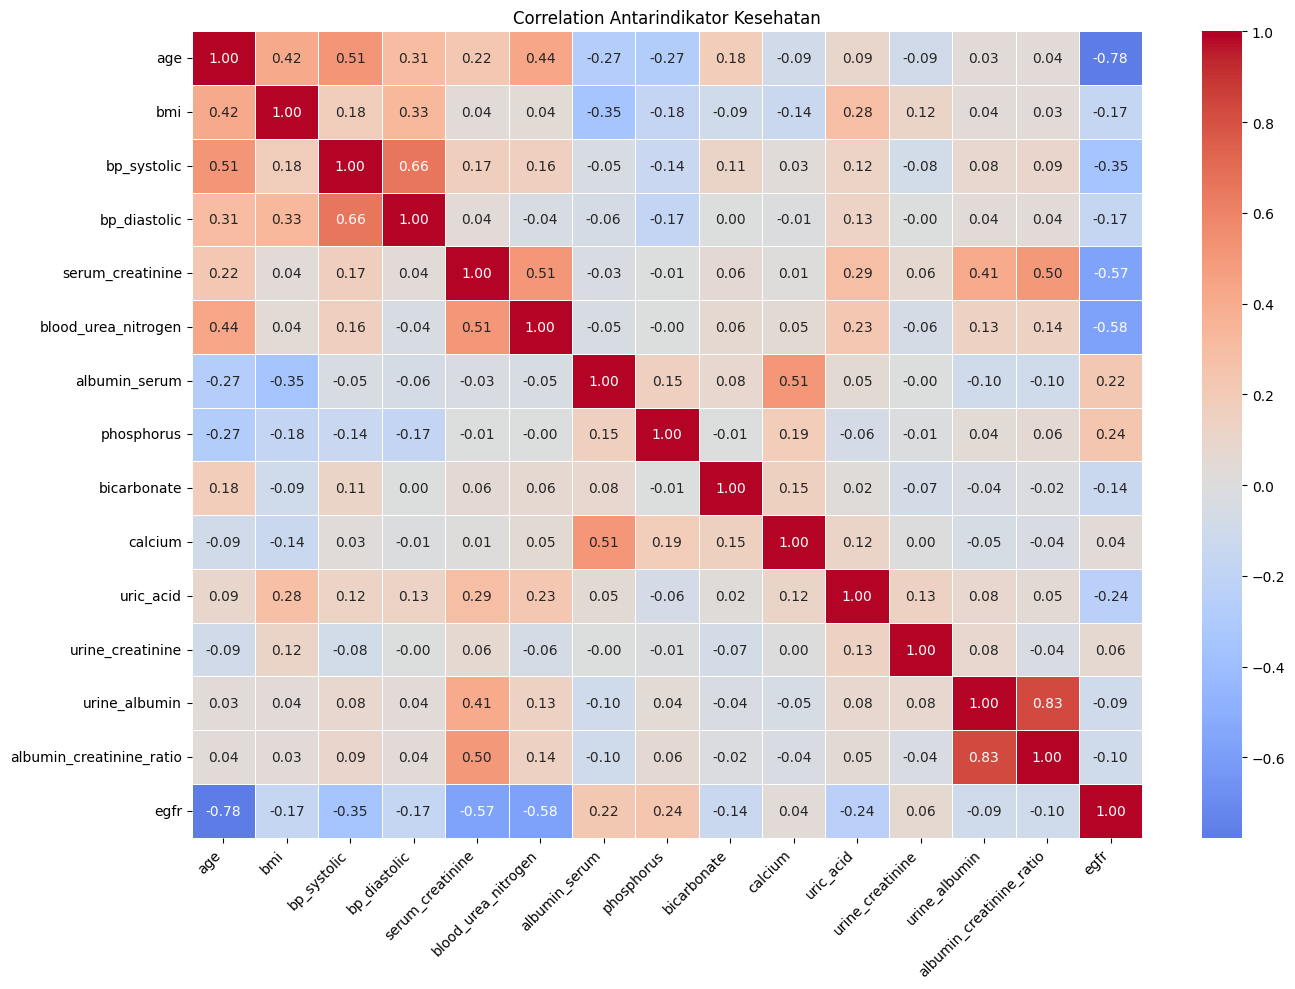

In [109]:
corr_cols = [
    'age',
    'bmi',
    'bp_systolic',
    'bp_diastolic',
    'serum_creatinine',
    'blood_urea_nitrogen',
    'albumin_serum',
    'phosphorus',
    'bicarbonate',
    'calcium',
    'uric_acid',
    'urine_creatinine',
    'urine_albumin',
    'albumin_creatinine_ratio',
    'egfr'
]

corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Antarindikator Kesehatan')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [110]:
TARGET = "ckd_present"

DROP_FEATURES = [
    "participant_id",
    "ckd_stage",
    "egfr"
]

X = df.drop(columns=[TARGET] + DROP_FEATURES, errors="ignore")
y = df[TARGET]

In [111]:
print("Jumlah fitur:", X.shape[1])
print("Fitur:")
print(X.columns.tolist())

Jumlah fitur: 25
Fitur:
['age', 'gender', 'ethnicity', 'education_level', 'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'insulin_use', 'diabetes_pills', 'ever_smoked', 'current_smoker']


In [112]:
categorical_features = [
    "gender",
    "ethnicity",
    "education_level",
    "diabetes_diagnosed",
    "ever_smoked",
    "current_smoker"
]

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'insulin_use', 'diabetes_pills']

Categorical features:
['gender', 'ethnicity', 'education_level', 'diabetes_diagnosed', 'ever_smoked', 'current_smoker']


In [113]:
for col in [
    "education_level",
    "diabetes_diagnosed",
    "ever_smoked",
    "current_smoker"
]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).sort_index())


education_level
education_level
1.0     373
2.0     666
3.0    1749
4.0    2370
5.0    2625
9.0      11
NaN    4139
Name: count, dtype: int64

diabetes_diagnosed
diabetes_diagnosed
1.0     1081
2.0    10371
3.0      284
9.0        4
NaN      193
Name: count, dtype: int64

ever_smoked
ever_smoked
1.0    3243
2.0    4878
7.0       7
9.0       7
NaN    3798
Name: count, dtype: int64

current_smoker
current_smoker
1.0     952
2.0     238
3.0    2053
NaN    8690
Name: count, dtype: int64


# TRAIN-TEST SPLIT

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (9546, 25)
Testing : (2387, 25)


# PREPROCESSING

In [115]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

In [116]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# MODEL TRAINING

In [117]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        verbosity=-1
    )
}

In [118]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

# CROSS-VALIDATION & MODEL COMPARISON

In [119]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [120]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [121]:
cv_results = []

for name, pipeline in pipelines.items():

    print(f"Evaluating {name}...")

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall/Sensitivity": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating LightGBM...


In [122]:
results_df = pd.DataFrame(cv_results)

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall/Sensitivity,F1,ROC-AUC
3,LightGBM,0.992353,0.995796,0.993256,0.994523,0.999740
2,XGBoost,0.990258,0.994145,0.991908,0.993024,0.999573
1,Random Forest,0.970878,0.982808,0.975423,0.979096,0.996559
0,Logistic Regression,0.866854,0.870924,0.950396,0.908922,0.900811


# HYPERPARAMETER TUNING

In [123]:
top3_models = results_df.head(3)["Model"].tolist()

print("Top 3 Models:")
for i, model in enumerate(top3_models, 1):
    print(f"{i}. {model}")

Top 3 Models:
1. LightGBM
2. XGBoost
3. Random Forest


In [124]:
rf_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

In [125]:
xgb_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [126]:
lgbm_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [-1, 3, 5, 7, 10],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves": [15, 31, 50, 70],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}

In [127]:
param_grids = {
    "Random Forest": rf_params,
    "XGBoost": xgb_params,
    "LightGBM": lgbm_params
}

In [128]:
tuned_models = {}
tuning_results = []

for name in top3_models:

    print(f"\nTuning {name}...")

    search = RandomizedSearchCV(
        estimator=pipelines[name],
        param_distributions=param_grids[name],
        n_iter=20,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    tuned_models[name] = search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best ROC-AUC": search.best_score_,
        "Best Parameters": search.best_params_
    })


Tuning LightGBM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [129]:
tuning_df = pd.DataFrame(tuning_results)

tuning_df

,Model,Best ROC-AUC,Best Parameters
0,LightGBM,0.999768,"{'model__subsample': 1.0, 'model__num_leaves':..."
1,XGBoost,0.999643,"{'model__subsample': 0.8, 'model__n_estimators..."
2,Random Forest,0.996507,"{'model__n_estimators': 500, 'model__min_sampl..."


In [130]:
best_index = tuning_df["Best ROC-AUC"].idxmax()

final_model_name = tuning_df.loc[
    best_index,
    "Model"
]

final_model = tuned_models[final_model_name]

print("Final Model:", final_model_name)

Final Model: LightGBM


# FINAL MODEL

In [131]:
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

y_pred_proba = final_model.predict_proba(X_test)[:, 1]

In [132]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

specificity = tn / (tn + fp)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity/Recall",
        "Specificity",
        "F1-Score",
        "ROC-AUC"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc
    ]
})

final_metrics

,Metric,Score
0,Accuracy,0.993716
1,Precision,0.996993
2,Sensitivity/Recall,0.994005
3,Specificity,0.993046
4,F1-Score,0.995497
5,ROC-AUC,0.999842


In [133]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-CKD", "CKD"]
    )
)

              precision    recall  f1-score   support

     Non-CKD       0.99      0.99      0.99       719
         CKD       1.00      0.99      1.00      1668

    accuracy                           0.99      2387
   macro avg       0.99      0.99      0.99      2387
weighted avg       0.99      0.99      0.99      2387



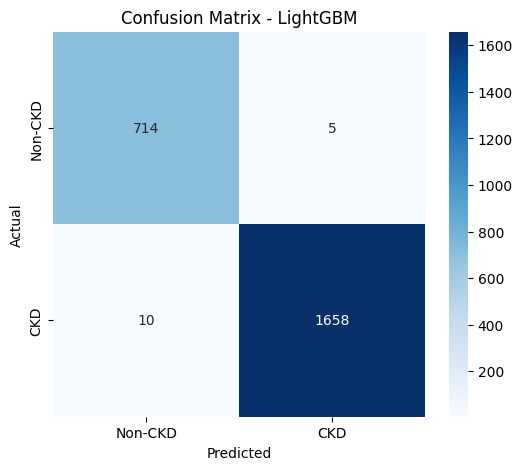

In [134]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-CKD", "CKD"],
    yticklabels=["Non-CKD", "CKD"]
)

plt.title(f"Confusion Matrix - {final_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

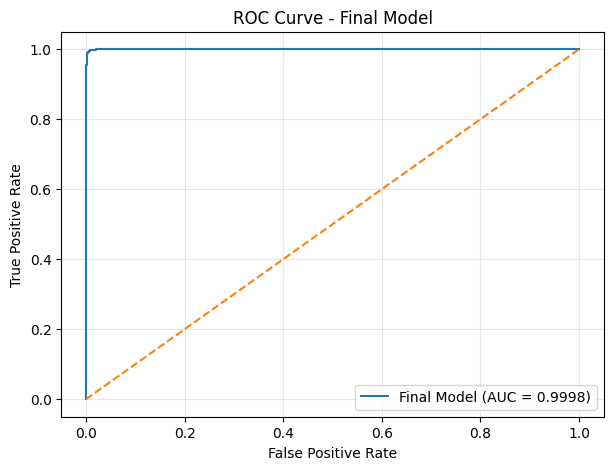

In [135]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = final_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

auc = roc_auc_score(
    y_test,
    y_proba
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"Final Model (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

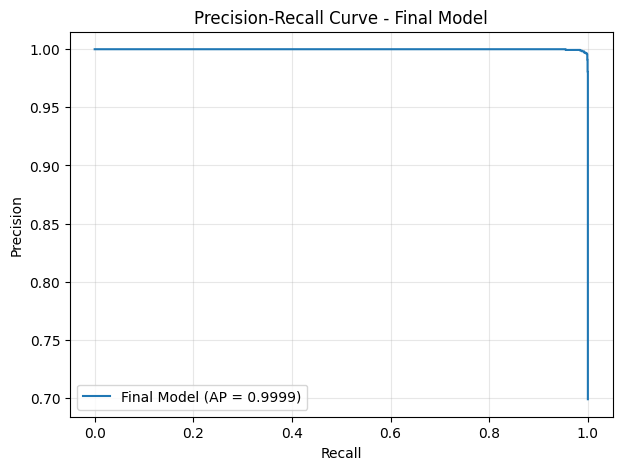

In [136]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_proba
)

ap = average_precision_score(
    y_test,
    y_proba
)

plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision,
    label=f"Final Model (AP = {ap:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final Model")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [137]:
preprocessor_final = final_model.named_steps["preprocessor"]

feature_names = preprocessor_final.get_feature_names_out()

model_object = final_model.named_steps["model"]

In [138]:
if hasattr(model_object, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_object.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    )

    importance_df.head(15)

In [139]:
feature_names = preprocessor_final.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model_object.feature_importances_
})
importance_df["Original_Feature"] = importance_df["Feature"].apply(
    lambda x: x.split("__", 1)[-1].split("_", 1)[0]
)

aggregated_importance = (
    importance_df
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

print("\n=== FEATURE IMPORTANCE BERDASARKAN FITUR ASLI ===")
print(aggregated_importance.head(15))


=== FEATURE IMPORTANCE BERDASARKAN FITUR ASLI ===
   Original_Feature  Importance
17            serum        4258
0               age        3297
1           albumin        1272
5                bp         755
12           gender         701
3             blood         605
19            urine         595
18             uric         585
15       phosphorus         518
13           height         510
2       bicarbonate         495
16          poverty         312
6           calcium         302
4               bmi         279
20           weight         258


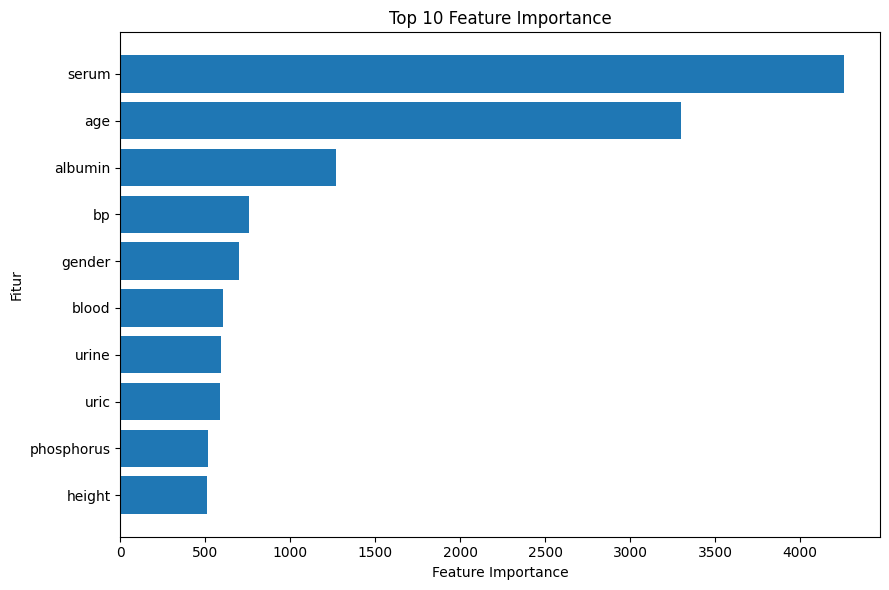

In [140]:
# Top 10 Feature Importance
top10 = (
    aggregated_importance
    .sort_values("Importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 6))

plt.barh(
    top10["Original_Feature"][::-1],
    top10["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Fitur")
plt.title("Top 10 Feature Importance")

plt.tight_layout()
plt.show()

In [141]:
preprocessor_final = final_model.named_steps["preprocessor"]
model_object = final_model.named_steps["model"]

X_test_transformed = preprocessor_final.transform(X_test)

feature_names = preprocessor_final.get_feature_names_out()

# SHAP Tree Explainer
explainer = shap.TreeExplainer(model_object)

# Hitung SHAP value
shap_values = explainer.shap_values(X_test_transformed)

# Untuk binary classification
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

shap_values_plot = np.asarray(shap_values_plot)

print("Shape X_test:", X_test_transformed.shape)
print("Shape SHAP:", shap_values_plot.shape)

Shape X_test: (2387, 44)
Shape SHAP: (2387, 44)


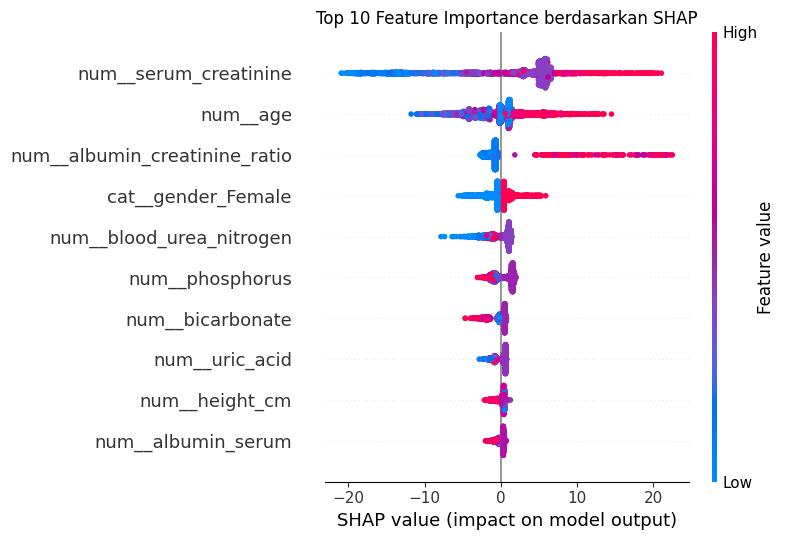

In [142]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names,
    max_display=10,
    show=False
)

plt.title("Top 10 Feature Importance berdasarkan SHAP")
plt.tight_layout()
plt.show()

In [143]:
mean_abs_shap = np.abs(shap_values_plot).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature_Preprocessed": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

# Mapping nama preprocessing -> nama fitur asli
def get_original_feature(name):
    name = str(name)

    # Hilangkan prefix transformer
    if "__" in name:
        name = name.split("__", 1)[1]

    # Mapping fitur kategorikal hasil encoding
    categorical_features = ["gender", "ethnicity"]

    for feature in categorical_features:
        if name.startswith(feature + "_"):
            return feature

    return name


shap_df["Original_Feature"] = (
    shap_df["Feature_Preprocessed"]
    .apply(get_original_feature)
)

# Agregasi kembali ke fitur asli
shap_aggregated = (
    shap_df
    .groupby("Original_Feature", as_index=False)["Mean_Absolute_SHAP"]
    .sum()
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
)

print("\n=== SHAP IMPORTANCE FITUR ASLI ===")
print(shap_aggregated.head(15))


=== SHAP IMPORTANCE FITUR ASLI ===
            Original_Feature  Mean_Absolute_SHAP
33          serum_creatinine            7.051490
0                        age            3.014954
1   albumin_creatinine_ratio            1.992955
28                    gender            1.755656
4        blood_urea_nitrogen            1.336575
31                phosphorus            1.194977
3                bicarbonate            0.807871
34                 uric_acid            0.766634
29                 height_cm            0.464281
2              albumin_serum            0.417769
8                    calcium            0.256355
6               bp_diastolic            0.225507
7                bp_systolic            0.165641
32      poverty_income_ratio            0.108923
37                 weight_kg            0.106150


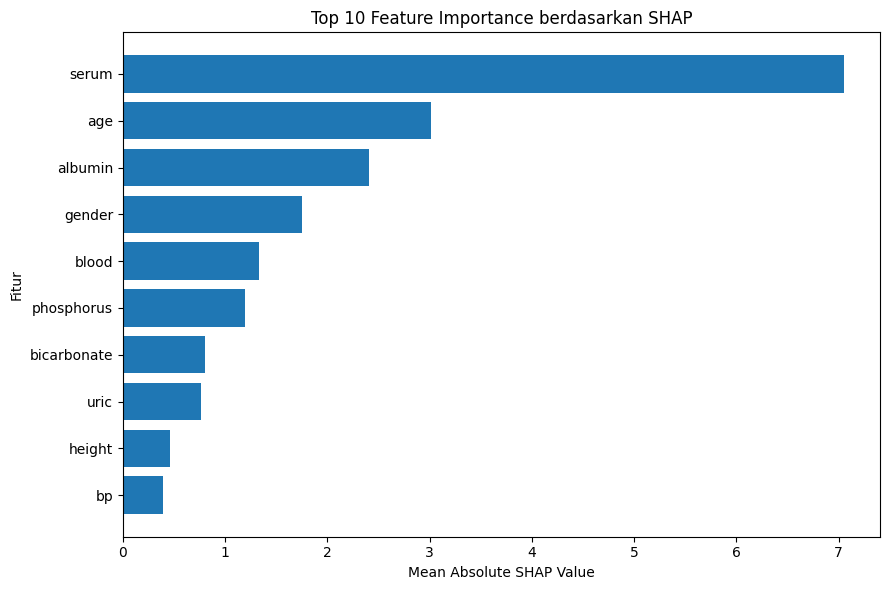

In [144]:
shap_abs = np.abs(shap_values_plot).mean(axis=0)

shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Absolute_SHAP': shap_abs
})

shap_importance['Original_Feature'] = shap_importance['Feature'].apply(
    lambda x: x.split('__', 1)[-1].split('_', 1)[0]
)

shap_aggregated = (
    shap_importance
    .groupby('Original_Feature', as_index=False)['Mean_Absolute_SHAP']
    .sum()
    .sort_values('Mean_Absolute_SHAP', ascending=False)
)

top10_shap = (
    shap_aggregated
    .head(10)
    .sort_values("Mean_Absolute_SHAP", ascending=True) # Sort ascending for correct barh order
)

plt.figure(figsize=(9, 6))

plt.barh(
    top10_shap["Original_Feature"],
    top10_shap["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Fitur")
plt.title("Top 10 Feature Importance berdasarkan SHAP")

plt.tight_layout()
plt.show()

In [145]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds_to_test:

    y_pred_threshold = (
        y_pred_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    specificity = tn / (tn + fp)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Specificity": specificity,
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,Threshold,Precision,Recall,Specificity,F1
0,0.3,0.996403,0.996403,0.991655,0.996403
1,0.4,0.996997,0.995204,0.993046,0.996100
2,0.5,0.996993,0.994005,0.993046,0.995497
3,0.6,0.997590,0.992806,0.994437,0.995192
4,0.7,0.997590,0.992806,0.994437,0.995192


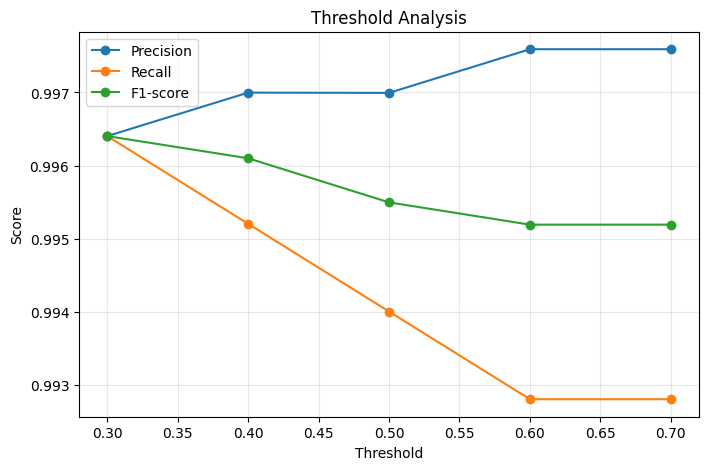

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [153]:
joblib.dump(
    final_model,
    "ckd_final_pipeline.joblib"
)

['ckd_final_pipeline.joblib']

In [154]:
loaded_model = joblib.load(
    "ckd_final_pipeline.joblib"
)

In [155]:
test_prediction = loaded_model.predict(
    X_test.head(5)
)

print(test_prediction)

[1 1 0 0 0]


In [157]:
results_df.to_csv(
    "model_comparison_cv.csv",
    index=False
)

tuning_df.to_csv(
    "model_tuning_results.csv",
    index=False
)

final_metrics.to_csv(
    "final_model_metrics.csv",
    index=False
)